# 🧬 AML Model Comparison Engine
**System:** Anti-Money Laundering Detection | Feature Fusion + Baseline + GNN Comparison

---

### Architecture
```
Module 1 : Load Sampled Transaction Graph (from Drive CSV, no Neo4j round-trips needed)
Module 2 : Graph Statistics       (in-degree, out-degree, PageRank via NetworkX)
Module 3 : Feature Fusion Layer   (aggregate Cycle + Layering + Smurfing + Threshold outputs)
Module 4 : Build Account-Level Feature Table + Ground-Truth Label
Module 5 : Random Forest Baseline (Accuracy, Precision, Recall, F1, ROC-AUC)
Module 6 : PyTorch Geometric Graph Construction
Module 7 : GraphSAGE Training & Evaluation
Module 8 : GAT Training & Evaluation
Module 9 : Model Comparison Table
```

### Design notes
- **Graph statistics use NetworkX**, not Neo4j GDS — consistent with the "no GDS/APOC"
  constraint from the Cycle Detection module. PageRank is a global, one-time computation,
  so it's cheaper to run once in Python on the sampled edge list than to query Aura
  iteratively.
- **The Feature Fusion Layer** is a dedicated module (Module 3) that maps each detection
  engine's differently-keyed output (`origin_account`, `hub_account`, `source_account`/
  `destination_account`, `account_id`) into one common `account_id` key, then aggregates
  with `max` (worst-case risk) and `count` (how many times that account was flagged).
- **Random Forest is trained first** as an interpretable, fast baseline — its metrics
  become the reference point Module 9 uses to quantify the GNN's actual performance gain.


---
## ⚙️ Setup
Mount Drive and install all required packages, including PyTorch Geometric.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas numpy scikit-learn networkx --quiet
!pip install torch torch_geometric --quiet

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.6 MB/s eta 0:00:00


---
## 📂 Shared Paths & Imports
Points to the outputs already produced by the Cycle, Layering, Smurfing, and
Threshold notebooks, plus the original sampled transaction CSV used to build
the Neo4j graph.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import ast
import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

BASE_DIR    = '/content/drive/MyDrive/AML System'
DATASET_DIR = f'{BASE_DIR}/datasets'
OUTPUT_DIR  = f'{BASE_DIR}/outputs'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRANSACTIONS_CSV = f'{DATASET_DIR}/aml_sampled_dataset.csv'

CYCLE_CSV      = f'{OUTPUT_DIR}/cycle_detection_results.csv'
LAYERING_CSV   = f'{OUTPUT_DIR}/layering_detection_results.csv'
SMURFING_CSV   = f'{OUTPUT_DIR}/smurfing_detection_results.csv'
THRESHOLD_CSV  = f'{OUTPUT_DIR}/threshold_detection_results.csv'

print('Paths configured ✓')
print(f'  Transactions : {TRANSACTIONS_CSV}')
print(f'  Cycle        : {CYCLE_CSV}')
print(f'  Layering     : {LAYERING_CSV}')
print(f'  Smurfing     : {SMURFING_CSV}')
print(f'  Threshold    : {THRESHOLD_CSV}')

Paths configured ✓
  Transactions : /content/drive/MyDrive/AML System/datasets/aml_sampled_dataset.csv
  Cycle        : /content/drive/MyDrive/AML System/outputs/cycle_detection_results.csv
  Layering     : /content/drive/MyDrive/AML System/outputs/layering_detection_results.csv
  Smurfing     : /content/drive/MyDrive/AML System/outputs/smurfing_detection_results.csv
  Threshold    : /content/drive/MyDrive/AML System/outputs/threshold_detection_results.csv


---
## MODULE 1 — Load Sampled Transaction Graph
---

### Cell 1 : Load Transactions & Build a Directed Graph
Reads the same sampled CSV used to populate Neo4j (so account IDs and edge
semantics match exactly across every notebook), then builds a NetworkX
`DiGraph` for computing structural statistics. Building this in Python avoids
another full-graph round-trip to Aura.

In [5]:
SENDER_COL = 'Account'
RECEIVER_COL = 'Account.1'

print('Loading transaction dataset...')

transactions_df = pd.read_csv(TRANSACTIONS_CSV)
print(f'Transactions loaded : {len(transactions_df):,}')
print(f'Columns             : {list(transactions_df.columns)}')
transactions_df.head()

Loading transaction dataset...
Transactions loaded : 350,000
Columns             : ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'from_account_id', 'to_account_id']


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,from_account_id,to_account_id
0,2022-09-01 00:01:00,70,100428660,27637,80518A110,4815.41,US Dollar,4815.41,US Dollar,Cash,0,70_100428660,27637_80518A110
1,2022-09-01 00:01:00,70,100428660,1244,8139D6C90,717.60,US Dollar,717.60,US Dollar,Cheque,0,70_100428660,1244_8139D6C90
2,2022-09-01 00:01:00,70,100428660,15980,80B39E7B0,792.92,US Dollar,792.92,US Dollar,Credit Card,1,70_100428660,15980_80B39E7B0
3,2022-09-01 00:01:00,70,100428660,795,805A0CB50,1681.93,US Dollar,1681.93,US Dollar,Cash,0,70_100428660,795_805A0CB50
4,2022-09-01 00:01:00,70,100428660,1047,80DF730B0,2020198.34,US Dollar,2020198.34,US Dollar,Cheque,0,70_100428660,1047_80DF730B0


In [6]:
# ── Fix: reconstruct account_id to match Neo4j's bank_account format ──
# Neo4j account_id = f"{Bank}_{Account}" (confirmed via Cypher inspection).
# If your raw transactions_df only has bare account codes, this rebuilds
# the SAME composite key here, so every downstream structure (graph stats,
# feature fusion, PyG node mapping) uses IDs that actually exist in Neo4j.

# Adjust these to your actual raw column names from the HI-Small schema —
# check transactions_df.columns if unsure
FROM_BANK_COL = 'From Bank'
TO_BANK_COL   = 'To Bank'

if FROM_BANK_COL in transactions_df.columns and TO_BANK_COL in transactions_df.columns:
    transactions_df[SENDER_COL] = (
        transactions_df[FROM_BANK_COL].astype(str) + '_' + transactions_df[SENDER_COL].astype(str)
    )
    transactions_df[RECEIVER_COL] = (
        transactions_df[TO_BANK_COL].astype(str) + '_' + transactions_df[RECEIVER_COL].astype(str)
    )
    print('✓ Reconstructed bank-prefixed account IDs to match Neo4j')
    print(transactions_df[[SENDER_COL, RECEIVER_COL]].head())
else:
    print(f'[WARNING] Could not find {FROM_BANK_COL}/{TO_BANK_COL} — check')
    print(f'transactions_df.columns: {list(transactions_df.columns)}')
    print('and adjust FROM_BANK_COL/TO_BANK_COL above to match.')

✓ Reconstructed bank-prefixed account IDs to match Neo4j
        Account        Account.1
0  70_100428660  27637_80518A110
1  70_100428660   1244_8139D6C90
2  70_100428660  15980_80B39E7B0
3  70_100428660    795_805A0CB50
4  70_100428660   1047_80DF730B0


In [7]:
# NOTE: adjust these column names if your sampled CSV uses different headers.
# Based on the earlier modules, the expected columns are:
#   sender account id, receiver account id, amount, timestamp, is_laundering
SENDER_COL     = 'Sender_Account'      # adjust to match your actual column name
RECEIVER_COL   = 'Receiver_Account'    # adjust to match your actual column name
AMOUNT_COL     = 'Amount_Paid'         # adjust to match your actual column name
LAUNDERING_COL = 'Is_Laundering'       # adjust to match your actual column name

missing_cols = [c for c in [SENDER_COL, RECEIVER_COL, AMOUNT_COL, LAUNDERING_COL]
                if c not in transactions_df.columns]

if missing_cols:
    print(f'[WARNING] These expected columns were not found: {missing_cols}')
    print(f'Actual columns available: {list(transactions_df.columns)}')
    print('Update the *_COL variables above to match your CSV before continuing.')
else:
    print('All expected columns found ✓')

[WARNING] These expected columns were not found: ['Sender_Account', 'Receiver_Account', 'Amount_Paid', 'Is_Laundering']
Actual columns available: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'from_account_id', 'to_account_id']
Update the *_COL variables above to match your CSV before continuing.


In [8]:
print('Building directed transaction graph in NetworkX...')

start = time.time()

G = nx.DiGraph()

for _, row in transactions_df.iterrows():
    sender   = row["Account"]
    receiver = row["Account.1"]
    amount   = row["Amount Received"]

    if G.has_edge(sender, receiver):
        # Accumulate weight/count if the same pair transacts multiple times
        G[sender][receiver]['weight'] += amount
        G[sender][receiver]['count']  += 1
    else:
        G.add_edge(sender, receiver, weight=amount, count=1)

print(f'Graph built in {time.time()-start:.1f}s')
print(f'  Nodes (accounts)    : {G.number_of_nodes():,}')
print(f'  Edges (unique pairs): {G.number_of_edges():,}')

Building directed transaction graph in NetworkX...
Graph built in 19.6s
  Nodes (accounts)    : 43,878
  Edges (unique pairs): 44,204


---
## MODULE 2 — Graph Statistics (Degree & PageRank)
---

### Cell 1 : Compute In-Degree, Out-Degree, and PageRank
These become node-level structural features. PageRank in particular captures
"importance" in the money-flow network — accounts that receive from many
important accounts get a higher score, which is a strong laundering-hub
signal that raw degree alone misses.

In [9]:
print('Computing graph statistics...')

start = time.time()

in_degree_dict  = dict(G.in_degree())
out_degree_dict = dict(G.out_degree())

# alpha=0.85 is the standard PageRank damping factor
pagerank_dict = nx.pagerank(G, alpha=0.85, weight='weight')

graph_stats_df = pd.DataFrame({
    'account_id' : list(G.nodes()),
})

graph_stats_df['in_degree']  = graph_stats_df['account_id'].map(in_degree_dict).fillna(0).astype(int)
graph_stats_df['out_degree'] = graph_stats_df['account_id'].map(out_degree_dict).fillna(0).astype(int)
graph_stats_df['total_degree'] = graph_stats_df['in_degree'] + graph_stats_df['out_degree']
graph_stats_df['pagerank']   = graph_stats_df['account_id'].map(pagerank_dict).fillna(0.0)

print(f'Graph statistics computed in {time.time()-start:.1f}s')
print(f'Accounts with graph stats : {len(graph_stats_df):,}')
graph_stats_df.sort_values('pagerank', ascending=False).head(10)

Computing graph statistics...
Graph statistics computed in 0.3s
Accounts with graph stats : 43,878


,account_id,in_degree,out_degree,total_degree,pagerank
0,70_100428660,523,14015,14538,0.008699
614,70_1004286A8,315,8585,8900,0.005247
1202,70_100428978,73,1688,1761,0.001231
6319,70_1004289C0,65,1311,1376,0.001098
14839,70_100428810,55,1227,1282,0.000932
3927,70_100428780,52,1311,1363,0.000882
474,70_100428738,47,1106,1153,0.000799
2863,70_1004287C8,46,1085,1131,0.000783
23775,70_1004288A0,44,924,968,0.000750
5705,70_1004286F0,43,1445,1488,0.000733


---
## MODULE 3 — Feature Fusion Layer
This module aggregates all four detection engines' outputs into one
`account_id`-keyed table. Each engine uses a different key column and a
different event granularity, so each is normalised individually before
being merged.
---

### Cell 1 : Fusion Helper Function
A single reusable function that takes any detection engine's output
DataFrame, the column(s) identifying the implicated account(s), and
produces a standardised `(account_id, {prefix}_risk_max, {prefix}_event_count)`
table. This keeps the fusion logic for all four engines consistent and DRY.

In [10]:
def fuse_detector_output(df: pd.DataFrame, account_cols: list, prefix: str) -> pd.DataFrame:
    """
    Normalise one detection engine's output into a per-account risk summary.

    Parameters
    ----------
    df            : the detector's raw output DataFrame (must have 'risk_score')
    account_cols  : list of column names that identify implicated accounts.
                    A single-column list (e.g. ['origin_account']) means each
                    row implicates one account. A multi-column list (e.g.
                    ['source_account', 'destination_account']) means each row
                    implicates multiple accounts, which are unpivoted so each
                    gets credited with that row's risk.
    prefix        : short engine name used to prefix output columns
                    (e.g. 'cycle', 'layering', 'smurfing', 'threshold')

    Returns
    -------
    DataFrame with columns: account_id, {prefix}_risk_max, {prefix}_event_count
    """
    if df.empty or 'risk_score' not in df.columns:
        return pd.DataFrame(columns=['account_id', f'{prefix}_risk_max', f'{prefix}_event_count'])

    # Unpivot multi-account rows so every implicated account gets its own row
    frames = []
    for col in account_cols:
        if col in df.columns:
            sub = df[[col, 'risk_score']].rename(columns={col: 'account_id'})
            frames.append(sub)

    if not frames:
        return pd.DataFrame(columns=['account_id', f'{prefix}_risk_max', f'{prefix}_event_count'])

    unpivoted = pd.concat(frames, ignore_index=True).dropna(subset=['account_id'])

    fused = unpivoted.groupby('account_id').agg(
        **{
            f'{prefix}_risk_max'    : ('risk_score', 'max'),
            f'{prefix}_event_count' : ('risk_score', 'count'),
        }
    ).reset_index()

    return fused


print('Fusion helper defined ✓')

Fusion helper defined ✓


### Cell 2 : Load & Fuse Each Detection Engine's Output
Each engine's CSV is loaded (if it exists — some may be empty if a module
found nothing) and passed through the fusion helper with its correct account
column mapping.

In [11]:
def safe_load_csv(path, label):
    """Load a CSV if it exists and is non-empty, otherwise return an empty DataFrame."""
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            print(f'  {label:<12} : {len(df):>6} rows loaded')
            return df
        except pd.errors.EmptyDataError:
            print(f'  {label:<12} :      0 rows (empty file)')
            return pd.DataFrame()
    else:
        print(f'  {label:<12} : file not found, skipping')
        return pd.DataFrame()


print('Loading detection engine outputs...')
cycle_results     = safe_load_csv(CYCLE_CSV,     'Cycle')
layering_results  = safe_load_csv(LAYERING_CSV,  'Layering')
smurfing_results  = safe_load_csv(SMURFING_CSV,  'Smurfing')
threshold_results = safe_load_csv(THRESHOLD_CSV, 'Threshold')

Loading detection engine outputs...
  Cycle        :    169 rows loaded
  Layering     :   1227 rows loaded
  Smurfing     :     24 rows loaded
  Threshold    : file not found, skipping


In [12]:
print('Fusing each engine into account-level risk summaries...\n')

fused_cycle = fuse_detector_output(
    cycle_results, account_cols=['origin_account'], prefix='cycle'
)
print(f'Cycle fused      : {len(fused_cycle)} unique accounts')

fused_layering = fuse_detector_output(
    layering_results, account_cols=['hub_account'], prefix='layering'
)
print(f'Layering fused   : {len(fused_layering)} unique accounts')

fused_smurfing = fuse_detector_output(
    smurfing_results, account_cols=['source_account', 'destination_account'], prefix='smurfing'
)
print(f'Smurfing fused   : {len(fused_smurfing)} unique accounts')

fused_threshold = fuse_detector_output(
    threshold_results, account_cols=['account_id'], prefix='threshold'
)
print(f'Threshold fused  : {len(fused_threshold)} unique accounts')

Fusing each engine into account-level risk summaries...

Cycle fused      : 9 unique accounts
Layering fused   : 370 unique accounts
Smurfing fused   : 45 unique accounts
Threshold fused  : 0 unique accounts


### Cell 3 : Merge All Four Fused Engines into One Table
Outer-joins all four engine summaries on `account_id` so accounts flagged by
only one or two engines are still included (with zeros for the engines that
didn't flag them) — this preserves negative examples for training.

In [13]:
fusion_frames = [fused_cycle, fused_layering, fused_smurfing, fused_threshold]
fusion_frames = [f for f in fusion_frames if not f.empty]

if fusion_frames:
    fused_features_df = fusion_frames[0]
    for frame in fusion_frames[1:]:
        fused_features_df = fused_features_df.merge(frame, on='account_id', how='outer')
else:
    fused_features_df = pd.DataFrame(columns=['account_id'])

# Fill missing engine columns with 0 — an account not flagged by an engine
# has zero risk and zero events from that engine, not a missing value
fused_features_df = fused_features_df.fillna(0)

print(f'Feature Fusion Layer complete ✓')
print(f'Accounts with at least one detector flag : {len(fused_features_df)}')
print(f'Fused feature columns : {[c for c in fused_features_df.columns if c != "account_id"]}')
fused_features_df.head()

Feature Fusion Layer complete ✓
Accounts with at least one detector flag : 371
Fused feature columns : ['cycle_risk_max', 'cycle_event_count', 'layering_risk_max', 'layering_event_count', 'smurfing_risk_max', 'smurfing_event_count']


,account_id,cycle_risk_max,cycle_event_count,layering_risk_max,layering_event_count,smurfing_risk_max,smurfing_event_count
0,10099_803D99E70,0.0,0.0,0.6245,3.0,0.0000,0.0
1,1024_80098A3D0,0.0,0.0,0.4635,3.0,0.5906,1.0
2,1047_811F41AC0,0.0,0.0,0.3304,1.0,0.0000,0.0
3,10709_80692A790,0.0,0.0,0.3317,1.0,0.0000,0.0
4,10_800119810,0.0,0.0,0.4800,1.0,0.0000,0.0


---
## MODULE 4 — Build Final Account-Level Feature Table + Label
---

### Cell 1 : Merge Fused Detector Features with Graph Statistics
Left-joins the fused detector risk scores onto the FULL graph statistics
table (every account in the graph, not just flagged ones), so the final
table has proper negative examples for classification, not only positives.

In [14]:
account_features_df = graph_stats_df.merge(
    fused_features_df, on='account_id', how='left'
)

# Accounts with no detector flags at all get 0 for every fused column
fused_cols = [c for c in fused_features_df.columns if c != 'account_id']
account_features_df[fused_cols] = account_features_df[fused_cols].fillna(0)

print(f'Final account feature table : {len(account_features_df)} accounts')
print(f'Total feature columns       : {len(account_features_df.columns) - 1}')
account_features_df.head()

Final account feature table : 43878 accounts
Total feature columns       : 10


,account_id,in_degree,out_degree,total_degree,pagerank,cycle_risk_max,cycle_event_count,layering_risk_max,layering_event_count,smurfing_risk_max,smurfing_event_count
0,70_100428660,523,14015,14538,0.008699,0.0,0.0,1.0,690.0,0.0,0.0
1,27637_80518A110,1,0,1,0.000019,0.0,0.0,0.0,0.0,0.0,0.0
2,1244_8139D6C90,1,0,1,0.000019,0.0,0.0,0.0,0.0,0.0,0.0
3,15980_80B39E7B0,1,0,1,0.000019,0.0,0.0,0.0,0.0,0.0,0.0
4,795_805A0CB50,1,0,1,0.000019,0.0,0.0,0.0,0.0,0.0,0.0


### Cell 2 : Derive Ground-Truth Account Label
An account is labeled positive (`1`) if it was the sender or receiver in
**any** transaction flagged `is_laundering=1` in the raw dataset. This label
is used for training and evaluation only — none of the fused features above
were built from it.

In [15]:
print('Deriving account-level ground-truth labels...')

# Local override based on user request for this cell
SENDER_COL = 'Account'
RECEIVER_COL = 'Account.1'

laundering_txns = transactions_df[transactions_df["Is Laundering"] == 1]

laundering_accounts = set(laundering_txns[SENDER_COL]) | set(laundering_txns[RECEIVER_COL])

account_features_df['label'] = account_features_df['account_id'].apply(
    lambda x: 1 if x in laundering_accounts else 0
)

print(f'Total accounts             : {len(account_features_df)}')
print(f'Positive (laundering) accts: {account_features_df["label"].sum()}')
print(f'Negative (clean) accounts  : {(account_features_df["label"] == 0).sum()}')
print(f'Positive class ratio       : {account_features_df["label"].mean():.2%}')

Deriving account-level ground-truth labels...
Total accounts             : 43878
Positive (laundering) accts: 5295
Negative (clean) accounts  : 38583
Positive class ratio       : 12.07%


In [16]:
OUTPUT_FEATURES_PATH = f'{OUTPUT_DIR}/account_level_features.csv'
account_features_df.to_csv(OUTPUT_FEATURES_PATH, index=False)
print(f'Account-level feature table saved: {OUTPUT_FEATURES_PATH}')
account_features_df.describe()

Account-level feature table saved: /content/drive/MyDrive/AML System/outputs/account_level_features.csv


,in_degree,out_degree,total_degree,pagerank,cycle_risk_max,cycle_event_count,layering_risk_max,layering_event_count,smurfing_risk_max,smurfing_event_count,label
count,43878.00000,43878.000000,43878.000000,43878.000000,43878.000000,43878.000000,43878.000000,43878.000000,43878.000000,43878.000000,43878.000000
mean,1.00743,1.007430,2.014859,0.000023,0.000109,0.003852,0.003497,0.027964,0.000526,0.001094,0.120676
std,3.05627,80.793844,83.794393,0.000052,0.007801,0.507400,0.040316,3.297486,0.016712,0.035064,0.325754
min,0.00000,0.000000,1.000000,0.000019,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.00000,0.000000,1.000000,0.000019,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.00000,0.000000,1.000000,0.000019,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.00000,0.000000,1.000000,0.000019,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,523.00000,14015.000000,14538.000000,0.008699,0.752200,93.000000,1.000000,690.000000,0.765800,2.000000,1.000000


---
## MODULE 5 — Random Forest Baseline
---

### Cell 1 : Train/Test Split
An 80/20 stratified split preserves the (likely small) positive class ratio
in both sets.

In [17]:
FEATURE_COLS = [c for c in account_features_df.columns if c not in ('account_id', 'label')]

X = account_features_df[FEATURE_COLS]
y = account_features_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Feature columns used ({len(FEATURE_COLS)}) : {FEATURE_COLS}')
print(f'Train set : {len(X_train)} accounts  ({y_train.sum()} positive)')
print(f'Test  set : {len(X_test)} accounts  ({y_test.sum()} positive)')

Feature columns used (10) : ['in_degree', 'out_degree', 'total_degree', 'pagerank', 'cycle_risk_max', 'cycle_event_count', 'layering_risk_max', 'layering_event_count', 'smurfing_risk_max', 'smurfing_event_count']
Train set : 35102 accounts  (4236 positive)
Test  set : 8776 accounts  (1059 positive)


### Cell 2 : Train Random Forest & Evaluate
Uses `class_weight='balanced'` to compensate for laundering being a rare
class, which is standard practice for AML classifiers. This baseline's
metrics are the reference point the GNN models must beat in Module 9.

In [18]:
print('Training Random Forest baseline...')

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_model.fit(X_train, y_train)
print(f'Training complete in {time.time()-start:.1f}s')

rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Compute the standard 5-metric evaluation suite for one model."""
    metrics = {
        'model'     : model_name,
        'accuracy'  : accuracy_score(y_true, y_pred),
        'precision' : precision_score(y_true, y_pred, zero_division=0),
        'recall'    : recall_score(y_true, y_pred, zero_division=0),
        'f1'        : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan'),
    }
    return metrics


rf_metrics = evaluate_model(y_test, rf_pred, rf_pred_prob, 'Random Forest')

print('\nRandom Forest Baseline Results:')
for k, v in rf_metrics.items():
    if k != 'model':
        print(f'  {k:<10}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Clean', 'Suspicious'], zero_division=0))

Training Random Forest baseline...
Training complete in 13.3s

Random Forest Baseline Results:
  accuracy  : 0.9201
  precision : 0.6310
  recall    : 0.8140
  f1        : 0.7109
  roc_auc   : 0.9240

Classification Report:
              precision    recall  f1-score   support

       Clean       0.97      0.93      0.95      7717
  Suspicious       0.63      0.81      0.71      1059

    accuracy                           0.92      8776
   macro avg       0.80      0.87      0.83      8776
weighted avg       0.93      0.92      0.92      8776



In [19]:
print('Top 15 most important features (Random Forest):')

importance_df = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'importance' : rf_model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(15)

Top 15 most important features (Random Forest):


,feature,importance
3,pagerank,0.575853
1,out_degree,0.212734
0,in_degree,0.110184
2,total_degree,0.092828
6,layering_risk_max,0.004332
7,layering_event_count,0.003749
8,smurfing_risk_max,0.000191
9,smurfing_event_count,0.000120
5,cycle_event_count,0.000007
4,cycle_risk_max,0.000002


# 🛑 Early-Stopped GraphSAGE & GAT Training
**Replaces:** Model Comparison Engine Modules 6–8 (train/test split + GraphSAGE + GAT)

---

### What changed from the original notebook
1. **Three-way split** — train / validation / test, instead of just train / test.
   Validation is carved out of the original training set only; the test set is
   untouched, so your final comparison numbers stay honest.
2. **Validation loss drives stopping**, not training loss — training loss will
   keep slowly improving from overfitting even after the model stops
   generalising better; validation loss is the signal that actually matters.
3. **GAT uses the settings you already validated**: dropout 0.1 (down from 0.3)
   and gradient-norm clipping at 1.0 — both confirmed to fix the spike
   instability you diagnosed via the loss-curve plots.
4. **Best-weights checkpointing** — the model state is saved whenever
   validation loss hits a new low, and reloaded at the end, so a lucky/unlucky
   final epoch never determines your reported metrics.

Run this notebook's cells in place of the original Modules 6, 7, and 8. Modules
1–5 (Feature Fusion, Random Forest baseline) and Module 9 (comparison table)
from the original notebook are unaffected and can be reused as-is.

---
## MODULE 6 (Revised) — PyTorch Geometric Graph + Train/Val/Test Split
---

### Cell 1 : Build the PyG Data Object
Identical to the original Module 6 Cell 1 — rebuild only if you're running
this notebook standalone. If `pyg_data` already exists in memory from the
original notebook run in this session, skip this cell.

In [20]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

print('Building PyTorch Geometric graph...')

# Fix a consistent node ordering matching account_features_df
account_features_df = account_features_df.reset_index(drop=True)
node_id_to_idx = {acc: i for i, acc in enumerate(account_features_df['account_id'])}

# Build edge_index directly from the transaction graph, filtering out any
# nodes that somehow didn't make it into account_features_df
edges = []
for sender, receiver in G.edges():
    if sender in node_id_to_idx and receiver in node_id_to_idx:
        edges.append((node_id_to_idx[sender], node_id_to_idx[receiver]))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Node features: everything except account_id and label, normalised 0-1
feature_matrix = account_features_df[FEATURE_COLS].values.astype(np.float32)
feature_min = feature_matrix.min(axis=0)
feature_max = feature_matrix.max(axis=0)
feature_range = np.where(feature_max - feature_min == 0, 1, feature_max - feature_min)
feature_matrix_norm = (feature_matrix - feature_min) / feature_range

x = torch.tensor(feature_matrix_norm, dtype=torch.float)
y_tensor = torch.tensor(account_features_df['label'].values, dtype=torch.long)

pyg_data = Data(x=x, edge_index=edge_index, y=y_tensor)

print(f'PyG graph built ✓')
print(f'  Nodes         : {pyg_data.num_nodes}')
print(f'  Edges         : {pyg_data.num_edges}')
print(f'  Node features : {pyg_data.num_node_features}')

Building PyTorch Geometric graph...
PyG graph built ✓
  Nodes         : 43878
  Edges         : 44204
  Node features : 10


In [21]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv
from sklearn.model_selection import train_test_split as tts
import numpy as np
import time
import copy

# Skip rebuilding if pyg_data already exists from the original notebook session
if 'pyg_data' not in globals():
    print('pyg_data not found in memory — rebuild it using Module 6 Cell 1')
    print('from the original Model Comparison Engine notebook before continuing.')
else:
    print('Reusing existing pyg_data from memory ✓')
    print(f'  Nodes : {pyg_data.num_nodes}')
    print(f'  Edges : {pyg_data.num_edges}')

Reusing existing pyg_data from memory ✓
  Nodes : 43878
  Edges : 44204


### Cell 2 : Three-Way Split — Train / Validation / Test
The test set (20%) is identical to before, for a fair final comparison.
The remaining 80% is now split again: 80% of that for actual training,
20% of that (16% of the total) held out as validation — used only to decide
when to stop, never to update weights.

In [22]:
indices = np.arange(pyg_data.num_nodes)
labels_np = pyg_data.y.cpu().numpy()

# First split: 80% train+val, 20% test (same test set as before)
trainval_idx, test_idx = tts(
    indices, test_size=0.20, random_state=42, stratify=labels_np
)

# Second split: carve validation out of the train+val portion only
train_idx, val_idx = tts(
    trainval_idx, test_size=0.20, random_state=42,
    stratify=labels_np[trainval_idx]
)

def make_mask(idx_array, num_nodes):
    mask = torch.zeros(num_nodes, dtype=torch.bool)
    mask[idx_array] = True
    return mask

train_mask = make_mask(train_idx, pyg_data.num_nodes)
val_mask   = make_mask(val_idx,   pyg_data.num_nodes)
test_mask  = make_mask(test_idx,  pyg_data.num_nodes)

pyg_data.train_mask = train_mask
pyg_data.val_mask   = val_mask
pyg_data.test_mask  = test_mask

print(f'Train nodes      : {train_mask.sum().item()}')
print(f'Validation nodes : {val_mask.sum().item()}')
print(f'Test nodes       : {test_mask.sum().item()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pyg_data = pyg_data.to(device)
print(f'Using device: {device}')

# Class weights computed from the TRAINING set only, matching the original approach
n_pos = (labels_np[train_idx] == 1).sum()
n_neg = (labels_np[train_idx] == 0).sum()
class_weights = torch.tensor(
    [1.0, n_neg / max(n_pos, 1)], dtype=torch.float
).to(device)

print(f'Class weights (clean, suspicious) : {class_weights.tolist()}')

Train nodes      : 28081
Validation nodes : 7021
Test nodes       : 8776
Using device: cpu
Class weights (clean, suspicious) : [1.0, 7.285924911499023]


### Cell 3 : Reusable Early-Stopping Training Loop
One shared function trains any PyG model with validation-based early stopping,
gradient clipping, and best-weight checkpointing — used by both GraphSAGE and
GAT below so the two models are trained under identical, comparable conditions.

In [23]:
def train_with_early_stopping(
    model, data, optimizer, class_weights,
    max_epochs=1500, patience=50, clip_norm=1.0,
    model_name='Model'
):
    """
    Train a PyG node-classification model with early stopping on validation loss.

    Parameters
    ----------
    model         : the PyG model instance (already moved to the correct device)
    data          : the PyG Data object with train_mask/val_mask/test_mask set
    optimizer     : a torch optimizer already attached to model.parameters()
    class_weights : tensor of per-class weights for the loss function
    max_epochs    : upper bound on training epochs — early stopping should
                    trigger well before this in most runs
    patience      : number of epochs with no validation improvement before
                    stopping. 50 is a reasonable default given the noisy
                    plateau behaviour observed in GAT's loss curve
    clip_norm     : max gradient norm — prevents the loss spikes seen before
                    dropout was lowered and clipping was added
    model_name    : used only for progress printing

    Returns
    -------
    train_losses, val_losses : lists of per-epoch loss values for plotting
    best_epoch                : the epoch at which the best validation loss occurred
    """
    train_losses = []
    val_losses   = []

    best_val_loss = float('inf')
    best_epoch    = 0
    best_state    = None
    epochs_without_improvement = 0

    print(f'Training {model_name} with early stopping (patience={patience})...')
    start = time.time()

    for epoch in range(1, max_epochs + 1):

        # ── Training step ─────────────────────────────────────────
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        train_loss = F.cross_entropy(
            out[data.train_mask], data.y[data.train_mask], weight=class_weights
        )
        train_loss.backward()

        # Gradient clipping — the fix confirmed to stabilise GAT training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)

        optimizer.step()
        train_losses.append(train_loss.item())

        # ── Validation step (no gradient updates) ───────────────────
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            val_loss = F.cross_entropy(
                out[data.val_mask], data.y[data.val_mask], weight=class_weights
            )
        val_losses.append(val_loss.item())

        # ── Early stopping bookkeeping ────────────────────────────
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 50 == 0:
            print(f'  Epoch {epoch:>4} | Train loss: {train_loss.item():.4f} | '
                  f'Val loss: {val_loss.item():.4f} | Best val: {best_val_loss:.4f} '
                  f'(epoch {best_epoch})')

        if epochs_without_improvement >= patience:
            print(f'\n  Early stopping triggered at epoch {epoch} '
                  f'(no improvement for {patience} epochs)')
            print(f'  Restoring best weights from epoch {best_epoch} '
                  f'(val loss: {best_val_loss:.4f})')
            break

    else:
        print(f'\n  Reached max_epochs={max_epochs} without triggering early stopping.')
        print(f'  Restoring best weights from epoch {best_epoch} '
              f'(val loss: {best_val_loss:.4f})')

    # Always restore the best checkpoint, not the final epoch's weights
    model.load_state_dict(best_state)

    elapsed = time.time() - start
    print(f'  Training complete in {elapsed:.1f}s — {len(train_losses)} epochs run')

    return train_losses, val_losses, best_epoch


print('Early-stopping training loop defined ✓')

Early-stopping training loop defined ✓


---
## MODULE 7 (Revised) — GraphSAGE with Early Stopping
---

### Cell 1 : Define, Train, and Evaluate GraphSAGE
Same architecture as the original notebook, now trained with the shared
early-stopping loop and gradient clipping for consistency with GAT.

In [24]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x


sage_model = GraphSAGE(
    in_channels=pyg_data.num_node_features,
    hidden_channels=64,
    out_channels=2
).to(device)

sage_optimizer = torch.optim.Adam(sage_model.parameters(), lr=0.01, weight_decay=5e-4)

sage_train_losses, sage_val_losses, sage_best_epoch = train_with_early_stopping(
    model=sage_model,
    data=pyg_data,
    optimizer=sage_optimizer,
    class_weights=class_weights,
    max_epochs=1500,
    patience=50,
    clip_norm=1.0,
    model_name='GraphSAGE'
)

Training GraphSAGE with early stopping (patience=50)...
  Epoch   50 | Train loss: 0.3166 | Val loss: 0.3121 | Best val: 0.3095 (epoch 48)
  Epoch  100 | Train loss: 0.3121 | Val loss: 0.3086 | Best val: 0.3082 (epoch 89)
  Epoch  150 | Train loss: 0.3104 | Val loss: 0.3080 | Best val: 0.3075 (epoch 148)
  Epoch  200 | Train loss: 0.3094 | Val loss: 0.3068 | Best val: 0.3066 (epoch 194)
  Epoch  250 | Train loss: 0.3083 | Val loss: 0.3080 | Best val: 0.3062 (epoch 212)

  Early stopping triggered at epoch 262 (no improvement for 50 epochs)
  Restoring best weights from epoch 212 (val loss: 0.3062)
  Training complete in 47.9s — 262 epochs run


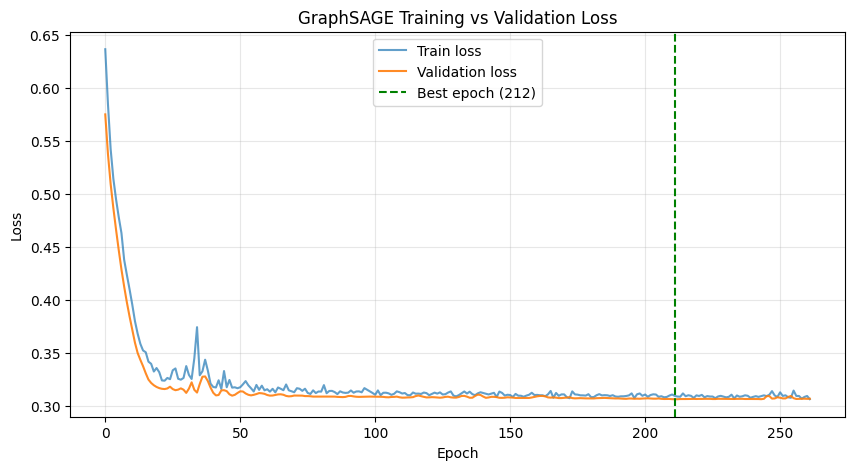

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sage_train_losses, label='Train loss', alpha=0.7)
plt.plot(sage_val_losses, label='Validation loss', alpha=0.9)
plt.axvline(sage_best_epoch - 1, color='green', linestyle='--', label=f'Best epoch ({sage_best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GraphSAGE Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
sage_model.eval()
with torch.no_grad():
    logits = sage_model(pyg_data.x, pyg_data.edge_index)
    probs = F.softmax(logits, dim=1)[:, 1]
    preds = logits.argmax(dim=1)

sage_y_true = pyg_data.y[pyg_data.test_mask].cpu().numpy()
sage_y_pred = preds[pyg_data.test_mask].cpu().numpy()
sage_y_prob = probs[pyg_data.test_mask].cpu().numpy()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_prob, model_name):
    return {
        'model'     : model_name,
        'accuracy'  : accuracy_score(y_true, y_pred),
        'precision' : precision_score(y_true, y_pred, zero_division=0),
        'recall'    : recall_score(y_true, y_pred, zero_division=0),
        'f1'        : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan'),
    }

sage_metrics = evaluate_model(sage_y_true, sage_y_pred, sage_y_prob, 'GraphSAGE (early-stopped)')

print('GraphSAGE (early-stopped) Test Results:')
for k, v in sage_metrics.items():
    if k != 'model':
        print(f'  {k:<10}: {v:.4f}')

GraphSAGE (early-stopped) Test Results:
  accuracy  : 0.9206
  precision : 0.6168
  recall    : 0.9027
  f1        : 0.7328
  roc_auc   : 0.9290


---
## MODULE 8 (Revised) — GAT with Early Stopping
(using your validated dropout=0.1 + gradient clipping settings)
---

### Cell 1 : Define, Train, and Evaluate GAT
Uses dropout=0.1 (down from the original 0.3) and lr=0.002, both confirmed via your loss-curve diagnostics to eliminate the spike instability seen at the original settings.

In [27]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.1)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.1)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv2(x, edge_index)
        return x


gat_model = GAT(
    in_channels=pyg_data.num_node_features,
    hidden_channels=16,
    out_channels=2,
    heads=4
).to(device)

gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.002, weight_decay=5e-4)

gat_train_losses, gat_val_losses, gat_best_epoch = train_with_early_stopping(
    model=gat_model,
    data=pyg_data,
    optimizer=gat_optimizer,
    class_weights=class_weights,
    max_epochs=1500,
    patience=50,
    clip_norm=1.0,
    model_name='GAT'
)

Training GAT with early stopping (patience=50)...
  Epoch   50 | Train loss: 0.5045 | Val loss: 0.4760 | Best val: 0.4760 (epoch 50)
  Epoch  100 | Train loss: 0.5729 | Val loss: 0.4240 | Best val: 0.4231 (epoch 92)
  Epoch  150 | Train loss: 0.5528 | Val loss: 0.4135 | Best val: 0.4102 (epoch 134)
  Epoch  200 | Train loss: 0.4581 | Val loss: 0.4027 | Best val: 0.4027 (epoch 200)
  Epoch  250 | Train loss: 0.4682 | Val loss: 0.4038 | Best val: 0.3966 (epoch 222)

  Early stopping triggered at epoch 272 (no improvement for 50 epochs)
  Restoring best weights from epoch 222 (val loss: 0.3966)
  Training complete in 95.8s — 272 epochs run


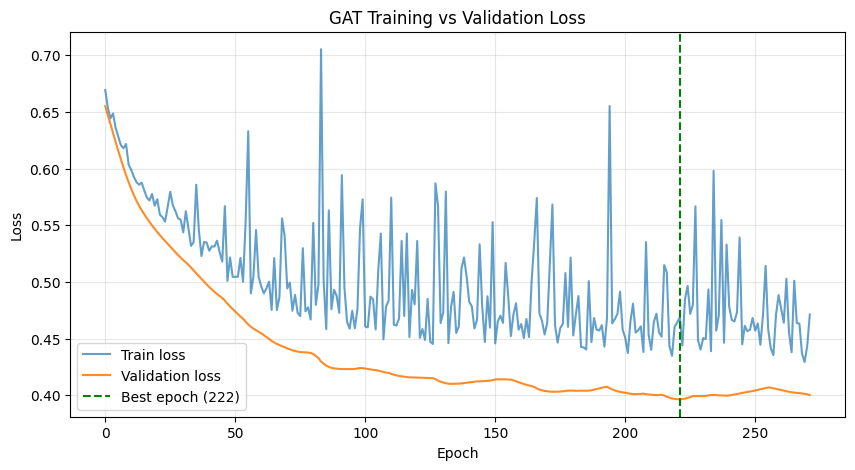

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(gat_train_losses, label='Train loss', alpha=0.7)
plt.plot(gat_val_losses, label='Validation loss', alpha=0.9)
plt.axvline(gat_best_epoch - 1, color='green', linestyle='--', label=f'Best epoch ({gat_best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAT Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
gat_model.eval()
with torch.no_grad():
    logits = gat_model(pyg_data.x, pyg_data.edge_index)
    probs = F.softmax(logits, dim=1)[:, 1]
    preds = logits.argmax(dim=1)

gat_y_true = pyg_data.y[pyg_data.test_mask].cpu().numpy()
gat_y_pred = preds[pyg_data.test_mask].cpu().numpy()
gat_y_prob = probs[pyg_data.test_mask].cpu().numpy()

gat_metrics = evaluate_model(gat_y_true, gat_y_pred, gat_y_prob, 'GAT (early-stopped)')

print('GAT (early-stopped) Test Results:')
for k, v in gat_metrics.items():
    if k != 'model':
        print(f'  {k:<10}: {v:.4f}')

GAT (early-stopped) Test Results:
  accuracy  : 0.8859
  precision : 0.5170
  recall    : 0.8338
  f1        : 0.6382
  roc_auc   : 0.8866


---
## MODULE 9 (Revised) — Updated Model Comparison
---

### Cell 1 : Compare Random Forest vs Early-Stopped GraphSAGE vs Early-Stopped GAT
Requires `rf_metrics` from the original notebook's Module 5 to still be in memory. If you're running this as a fresh session, re-run that cell first.

In [30]:
if 'rf_metrics' not in globals():
    print('rf_metrics not found — re-run Module 5 (Random Forest baseline) first.')
else:
    import pandas as pd

    comparison_df = pd.DataFrame([rf_metrics, sage_metrics, gat_metrics])
    comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

    print('=' * 75)
    print('UPDATED MODEL COMPARISON — Random Forest vs Early-Stopped GraphSAGE vs GAT')
    print('=' * 75)
    print(comparison_df.to_string(index=False))

    baseline_f1  = rf_metrics['f1']
    baseline_auc = rf_metrics['roc_auc']

    print('\nPerformance gain over Random Forest baseline:')
    for metrics in [sage_metrics, gat_metrics]:
        f1_gain  = ((metrics['f1']      - baseline_f1)  / baseline_f1  * 100) if baseline_f1  > 0 else float('nan')
        auc_gain = ((metrics['roc_auc'] - baseline_auc) / baseline_auc * 100) if baseline_auc > 0 else float('nan')
        print(f"  {metrics['model']:<28} | F1 gain: {f1_gain:+.1f}%  | ROC-AUC gain: {auc_gain:+.1f}%")

    comparison_df.to_csv(f'{OUTPUT_DIR}/model_comparison_results_earlystop.csv', index=False)
    print(f'\nSaved: {OUTPUT_DIR}/model_comparison_results_earlystop.csv')

UPDATED MODEL COMPARISON — Random Forest vs Early-Stopped GraphSAGE vs GAT
                    model  accuracy  precision   recall       f1  roc_auc
            Random Forest  0.920123   0.631040 0.813975 0.710928 0.923963
GraphSAGE (early-stopped)  0.920579   0.616774 0.902738 0.732848 0.929009
      GAT (early-stopped)  0.885939   0.516979 0.833805 0.638236 0.886614

Performance gain over Random Forest baseline:
  GraphSAGE (early-stopped)    | F1 gain: +3.1%  | ROC-AUC gain: +0.5%
  GAT (early-stopped)          | F1 gain: -10.2%  | ROC-AUC gain: -4.0%

Saved: /content/drive/MyDrive/AML System/outputs/model_comparison_results_earlystop.csv


# 🔗 Random Forest + GraphSAGE Ensemble
**Combines:** Random Forest's precision with GraphSAGE's recall

---

### Why ensemble here specifically
Random Forest and GraphSAGE aren't just different algorithms — they see
genuinely different information. Random Forest only sees each account's own
aggregated features (its fused detector risk scores, its degree, its
PageRank). GraphSAGE additionally propagates signal from an account's
*neighbors* through message passing. When two models disagree because they're
looking at different evidence, averaging their scores tends to cancel out
each model's blind spots rather than just averaging their mistakes.

### Method
This uses a **simple weighted average of predicted probabilities**, not a
stacked meta-model — deliberately, since a meta-model would need its own
separate validation split to avoid overfitting on only ~2 base models, and
the added complexity isn't justified when a weighted average is this
transparent and this easy to tune with one number.

### Requires (from earlier notebooks, must be in memory or reloaded)
- `rf_model`, `X_test`, `y_test` — from the Random Forest baseline module
- `sage_model`, `pyg_data` — from the (early-stopped) GraphSAGE training run
- Both must have been evaluated on the **same underlying test accounts** —
  Cell 1 below verifies this before anything else runs.

---
## Cell 1 : Verify Both Models Share the Same Test Set
Random Forest's `X_test`/`y_test` come from a pandas train_test_split;
GraphSAGE's test predictions come from `pyg_data.test_mask`. Both were built
from the same `account_features_df` with `random_state=42` and the same
`test_size=0.20`, so the underlying accounts should match — but we verify
this explicitly rather than assuming it, since silently misaligned rows would
silently corrupt every result below.

In [31]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

required_vars = ['rf_model', 'X_test', 'y_test', 'sage_model', 'pyg_data', 'account_features_df']
missing = [v for v in required_vars if v not in globals()]

if missing:
    print(f'[ERROR] Missing required variables: {missing}')
    print('Re-run the Random Forest baseline (Module 5) and the early-stopped')
    print('GraphSAGE training cell in this same Colab session before continuing.')
else:
    # Get the account_ids corresponding to X_test's row order
    rf_test_account_ids = account_features_df.loc[X_test.index, 'account_id'].values

    # Get the account_ids corresponding to pyg_data.test_mask, in mask order
    test_mask_np = pyg_data.test_mask.cpu().numpy()
    sage_test_account_ids = account_features_df.loc[test_mask_np, 'account_id'].values

    same_accounts = set(rf_test_account_ids) == set(sage_test_account_ids)

    print(f'Random Forest test accounts : {len(rf_test_account_ids)}')
    print(f'GraphSAGE test accounts     : {len(sage_test_account_ids)}')
    print(f'Same underlying test set    : {same_accounts}')

    if not same_accounts:
        print('\n[WARNING] Test sets do not match! This means the two models were')
        print('evaluated on different accounts, and their scores cannot be validly')
        print('combined row-by-row below. Re-check that both splits used the same')
        print('random_state and test_size, or rebuild pyg_data.test_mask to match')
        print('X_test.index exactly.')
    else:
        print('\n✓ Test sets verified identical — safe to combine scores directly.')

Random Forest test accounts : 8776
GraphSAGE test accounts     : 8776
Same underlying test set    : True

✓ Test sets verified identical — safe to combine scores directly.


---
## Cell 2 : Align Both Models' Probabilities to One Common Table
Builds a single DataFrame indexed by `account_id`, with each model's
predicted probability of being "suspicious" (class 1) in its own column —
this is the shared foundation every ensemble weighting below reads from.

In [32]:
# Random Forest probabilities (already computed as rf_pred_prob earlier,
# but recomputed here to keep this notebook self-contained)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

rf_scores_df = pd.DataFrame({
    'account_id': rf_test_account_ids,
    'rf_prob'   : rf_probs,
    'true_label': y_test.values
})

# GraphSAGE probabilities on the same test-masked nodes
sage_model.eval()
with torch.no_grad():
    logits = sage_model(pyg_data.x, pyg_data.edge_index)
    sage_probs_all = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

sage_scores_df = pd.DataFrame({
    'account_id': sage_test_account_ids,
    'sage_prob' : sage_probs_all[test_mask_np]
})

# Merge on account_id — inner join guarantees only accounts scored by both models
ensemble_df = rf_scores_df.merge(sage_scores_df, on='account_id', how='inner')

print(f'Accounts scored by both models : {len(ensemble_df)}')
ensemble_df.head()

Accounts scored by both models : 8776


,account_id,rf_prob,true_label,sage_prob
0,25536_802EE9000,0.084637,0,0.119640
1,15010_8021BF9C0,0.126554,0,0.119640
2,19474_80E50C8F0,0.087655,0,0.105746
3,48211_811DC5FC0,0.828626,0,0.824127
4,10614_8124D4010,0.105921,0,0.105746


---
## Cell 3 : Sweep Ensemble Weights
Rather than guessing a 50/50 split, this sweeps the RF/GraphSAGE weighting from 0 (pure GraphSAGE) to 1 (pure Random Forest) in steps of 0.1, and reports F1 and ROC-AUC at each — so the final weight choice is backed by evidence, not intuition.

In [33]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

DETECTION_THRESHOLD = 0.5   # standard midpoint threshold for the ensembled probability

sweep_results = []

for rf_weight in np.arange(0.0, 1.01, 0.1):
    sage_weight = 1.0 - rf_weight

    ensemble_prob = (rf_weight * ensemble_df['rf_prob']) + (sage_weight * ensemble_df['sage_prob'])
    ensemble_pred = (ensemble_prob >= DETECTION_THRESHOLD).astype(int)

    sweep_results.append({
        'rf_weight'   : round(rf_weight, 1),
        'sage_weight' : round(sage_weight, 1),
        'accuracy'    : accuracy_score(ensemble_df['true_label'], ensemble_pred),
        'precision'   : precision_score(ensemble_df['true_label'], ensemble_pred, zero_division=0),
        'recall'      : recall_score(ensemble_df['true_label'], ensemble_pred, zero_division=0),
        'f1'          : f1_score(ensemble_df['true_label'], ensemble_pred, zero_division=0),
        'roc_auc'     : roc_auc_score(ensemble_df['true_label'], ensemble_prob),
    })

sweep_df = pd.DataFrame(sweep_results)

print('Ensemble weight sweep (rf_weight = 0 is pure GraphSAGE, 1 is pure Random Forest):')
print(sweep_df.to_string(index=False))

best_f1_row  = sweep_df.loc[sweep_df['f1'].idxmax()]
best_auc_row = sweep_df.loc[sweep_df['roc_auc'].idxmax()]

print(f"\nBest F1      : rf_weight={best_f1_row['rf_weight']}  →  F1={best_f1_row['f1']:.4f}")
print(f"Best ROC-AUC : rf_weight={best_auc_row['rf_weight']}  →  ROC-AUC={best_auc_row['roc_auc']:.4f}")

Ensemble weight sweep (rf_weight = 0 is pure GraphSAGE, 1 is pure Random Forest):
 rf_weight  sage_weight  accuracy  precision   recall       f1  roc_auc
       0.0          1.0  0.920579   0.616774 0.902738 0.732848 0.929009
       0.1          0.9  0.920693   0.617021 0.903683 0.733333 0.940482
       0.2          0.8  0.920693   0.617021 0.903683 0.733333 0.940351
       0.3          0.7  0.920807   0.617419 0.903683 0.733614 0.940106
       0.4          0.6  0.921149   0.618464 0.904627 0.734663 0.939509
       0.5          0.5  0.921376   0.620509 0.897073 0.733591 0.939294
       0.6          0.4  0.922174   0.628944 0.865911 0.728645 0.939148
       0.7          0.3  0.921490   0.629010 0.851747 0.723626 0.938773
       0.8          0.2  0.921149   0.631730 0.830973 0.717781 0.937167
       0.9          0.1  0.921263   0.634700 0.818697 0.715052 0.934456
       1.0          0.0  0.920123   0.631040 0.813975 0.710928 0.923963

Best F1      : rf_weight=0.4  →  F1=0.7347
Best ROC-A

---
## Cell 4 : Visualize the Sweep
Plots F1, precision, recall, and ROC-AUC against the RF weighting, so you can see the full precision/recall tradeoff curve rather than just the two single-point optima printed above.

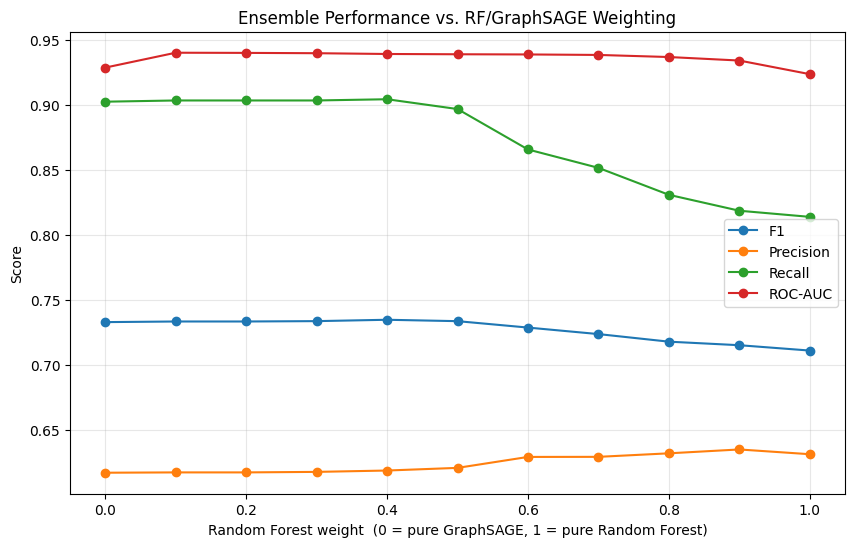

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sweep_df['rf_weight'], sweep_df['f1'],        marker='o', label='F1')
ax.plot(sweep_df['rf_weight'], sweep_df['precision'],  marker='o', label='Precision')
ax.plot(sweep_df['rf_weight'], sweep_df['recall'],     marker='o', label='Recall')
ax.plot(sweep_df['rf_weight'], sweep_df['roc_auc'],    marker='o', label='ROC-AUC')

ax.set_xlabel('Random Forest weight  (0 = pure GraphSAGE, 1 = pure Random Forest)')
ax.set_ylabel('Score')
ax.set_title('Ensemble Performance vs. RF/GraphSAGE Weighting')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## Cell 5 : Final Ensemble — Comparison Against Both Standalone Models
Uses the F1-optimal weight found above to build the final ensemble, then places it side-by-side with the standalone Random Forest, GraphSAGE, and GAT results for a complete final comparison table.

In [35]:
# ── Cell 5 (Recall-Optimized) ──────────────────────────────────────
# Instead of the F1-optimal weight, select the weighting that maximizes
# recall while keeping precision above a workable floor (0.45) — so
# investigators aren't flooded with alerts that are mostly noise.

PRECISION_FLOOR = 0.45  # minimum acceptable precision — tune based on investigator capacity

viable_rows = sweep_df[sweep_df['precision'] >= PRECISION_FLOOR]

if viable_rows.empty:
    print(f'[WARNING] No weighting achieves precision >= {PRECISION_FLOOR}.')
    print('Falling back to the single highest-recall row in the full sweep —')
    print('review this choice manually, as precision may be very low.')
    best_recall_row = sweep_df.loc[sweep_df['recall'].idxmax()]
else:
    best_recall_row = viable_rows.loc[viable_rows['recall'].idxmax()]

FINAL_RF_WEIGHT = float(best_recall_row['rf_weight'])
FINAL_SAGE_WEIGHT = 1.0 - FINAL_RF_WEIGHT

print(f'Recall-optimized weighting selected:')
print(f'  RF weight      : {FINAL_RF_WEIGHT}')
print(f'  GraphSAGE weight: {FINAL_SAGE_WEIGHT}')
print(f'  Recall         : {best_recall_row["recall"]:.4f}')
print(f'  Precision      : {best_recall_row["precision"]:.4f}  (floor: {PRECISION_FLOOR})')
print(f'  F1             : {best_recall_row["f1"]:.4f}')
print(f'  ROC-AUC        : {best_recall_row["roc_auc"]:.4f}')

final_ensemble_prob = (
    FINAL_RF_WEIGHT * ensemble_df['rf_prob'] +
    FINAL_SAGE_WEIGHT * ensemble_df['sage_prob']
)
final_ensemble_pred = (final_ensemble_prob >= DETECTION_THRESHOLD).astype(int)

ensemble_metrics = {
    'model'     : f'Ensemble Recall-Optimized (RF={FINAL_RF_WEIGHT}, SAGE={FINAL_SAGE_WEIGHT})',
    'accuracy'  : accuracy_score(ensemble_df['true_label'], final_ensemble_pred),
    'precision' : precision_score(ensemble_df['true_label'], final_ensemble_pred, zero_division=0),
    'recall'    : recall_score(ensemble_df['true_label'], final_ensemble_pred, zero_division=0),
    'f1'        : f1_score(ensemble_df['true_label'], final_ensemble_pred, zero_division=0),
    'roc_auc'   : roc_auc_score(ensemble_df['true_label'], final_ensemble_prob),
}

# Combine with the standalone results if they're available in memory
all_results = [ensemble_metrics]
if 'rf_metrics' in globals():
    all_results.append(rf_metrics)
if 'sage_metrics' in globals():
    all_results.append(sage_metrics)
if 'gat_metrics' in globals():
    all_results.append(gat_metrics)

final_comparison_df = pd.DataFrame(all_results)
final_comparison_df = final_comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

print('\n' + '=' * 80)
print('FINAL COMPARISON — Recall-Optimized Ensemble vs Standalone Models')
print('=' * 80)
print(final_comparison_df.to_string(index=False))

Recall-optimized weighting selected:
  RF weight      : 0.4
  GraphSAGE weight: 0.6
  Recall         : 0.9046
  Precision      : 0.6185  (floor: 0.45)
  F1             : 0.7347
  ROC-AUC        : 0.9395

FINAL COMPARISON — Recall-Optimized Ensemble vs Standalone Models
                                       model  accuracy  precision   recall       f1  roc_auc
Ensemble Recall-Optimized (RF=0.4, SAGE=0.6)  0.921149   0.618464 0.904627 0.734663 0.939509
                               Random Forest  0.920123   0.631040 0.813975 0.710928 0.923963
                   GraphSAGE (early-stopped)  0.920579   0.616774 0.902738 0.732848 0.929009
                         GAT (early-stopped)  0.885939   0.516979 0.833805 0.638236 0.886614


---
## Cell 6 : Save the Ensemble Scores & Comparison
Persists both the per-account ensemble predictions (for downstream dashboard/case-management use) and the final comparison table.

In [36]:
OUTPUT_DIR = '/content/drive/MyDrive/AML System/outputs'

ensemble_df['ensemble_prob'] = final_ensemble_prob
ensemble_df['ensemble_pred'] = final_ensemble_pred

def assign_risk_tier(score):
    if score >= 0.75:
        return 'CRITICAL'
    elif score >= 0.50:
        return 'HIGH'
    elif score >= 0.25:
        return 'MEDIUM'
    else:
        return 'LOW'

ensemble_df['risk_tier'] = ensemble_df['ensemble_prob'].apply(assign_risk_tier)

ensemble_df.to_csv(f'{OUTPUT_DIR}/ensemble_account_scores.csv', index=False)
final_comparison_df.to_csv(f'{OUTPUT_DIR}/final_model_comparison.csv', index=False)
sweep_df.to_csv(f'{OUTPUT_DIR}/ensemble_weight_sweep.csv', index=False)

print('Saved:')
print(f'  ✓ ensemble_account_scores.csv   ({len(ensemble_df)} rows — per-account scores)')
print(f'  ✓ final_model_comparison.csv    (all models side-by-side)')
print(f'  ✓ ensemble_weight_sweep.csv     (full weight sweep for reference)')
print()
print(f'Recommended production weighting: RF={FINAL_RF_WEIGHT}, GraphSAGE={FINAL_SAGE_WEIGHT}')
print()
print('Next: Week 6 — wrap this ensemble scoring logic in a FastAPI risk-scoring endpoint.')

Saved:
  ✓ ensemble_account_scores.csv   (8776 rows — per-account scores)
  ✓ final_model_comparison.csv    (all models side-by-side)
  ✓ ensemble_weight_sweep.csv     (full weight sweep for reference)

Recommended production weighting: RF=0.4, GraphSAGE=0.6

Next: Week 6 — wrap this ensemble scoring logic in a FastAPI risk-scoring endpoint.


In [37]:
"""
RUN THIS IN COLAB, not in the API project.

Paste this as a new cell at the END of your training notebook, after
rf_model, sage_model, account_features_df, and transactions_df all exist
in memory. It exports everything the FastAPI service needs into your
Drive outputs folder, ready to download into aml-api/app/models/.
"""

import joblib
import torch
import os

EXPORT_DIR = f'{OUTPUT_DIR}/api_export'
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── 1. Random Forest model ──────────────────────────────────────────
rf_path = f'{EXPORT_DIR}/rf_model.pkl'
joblib.dump(rf_model, rf_path)
print(f'✓ Saved Random Forest model: {rf_path}')

# ── 2. GraphSAGE weights (state_dict only, not the full object) ────
sage_path = f'{EXPORT_DIR}/graphsage_weights.pt'
torch.save(sage_model.state_dict(), sage_path)
print(f'✓ Saved GraphSAGE weights: {sage_path}')

# ── 3. Account-level feature table ──────────────────────────────────
features_path = f'{EXPORT_DIR}/account_level_features.csv'
account_features_df.to_csv(features_path, index=False)
print(f'✓ Saved account features: {features_path}  ({len(account_features_df)} accounts)')

# ── 4. Edge list — needed to rebuild the same graph structure ──────
# Uses the SAME column names the ScoringService expects: sender, receiver
edge_export_df = transactions_df[[SENDER_COL, RECEIVER_COL]].copy()
edge_export_df.columns = ['sender', 'receiver']
edge_export_df = edge_export_df.drop_duplicates()

edges_path = f'{EXPORT_DIR}/edge_list.csv'
edge_export_df.to_csv(edges_path, index=False)
print(f'✓ Saved edge list: {edges_path}  ({len(edge_export_df)} unique edges)')

print()
print('=' * 60)
print('Export complete. Download these 4 files from:')
print(f'  {EXPORT_DIR}')
print('and place them into:')
print('  aml-api/app/models/')
print('=' * 60)

✓ Saved Random Forest model: /content/drive/MyDrive/AML System/outputs/api_export/rf_model.pkl
✓ Saved GraphSAGE weights: /content/drive/MyDrive/AML System/outputs/api_export/graphsage_weights.pt
✓ Saved account features: /content/drive/MyDrive/AML System/outputs/api_export/account_level_features.csv  (43878 accounts)
✓ Saved edge list: /content/drive/MyDrive/AML System/outputs/api_export/edge_list.csv  (44204 unique edges)

Export complete. Download these 4 files from:
  /content/drive/MyDrive/AML System/outputs/api_export
and place them into:
  aml-api/app/models/
